In [262]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [263]:
import os
import sys

import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch

import numpy as np

from scipy.spatial.transform import Rotation as R
import random 

import time 
import pypose as pp 

import matplotlib.pyplot as plt

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)


from src.data_loader.data_module_lightning import SonarSimDataModule
from src.models.graph_train import Graph 
from src.models.utils import project_points, approx_movement, depth_to_elev_angle, ExtrinsicsCalib

In [264]:
model_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'
sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'
train_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/training.yaml'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
    model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
    sonar_config = Box(yaml.safe_load(f))

calib = ExtrinsicsCalib(T = [sonar_config.position.x, sonar_config.position.y, sonar_config.position.z],
                        R = [sonar_config.position.roll, sonar_config.position.pitch, sonar_config.position.yaw])

patches_per_frame = model_config.PATCHES_PER_FRAME
patch_size = model_config.PATCH_SIZE
encoder_downsize = model_config.ENCODER_DOWNSIZE
corr_neighbour = model_config.CORR_NEIGHBOUR

scale_factor = torch.tensor([
            model_config.FLS_INPUT_HEIGHT / (sonar_config.range.max - sonar_config.range.min),
            model_config.FLS_INPUT_WIDTH / sonar_config.fov.horizontal
        ]).view(1, 2)

graph = Graph(model_config, sonar_config, batch_size = 1, frames_in_series = 2)
            
root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/selfsupervised'
batch_size = 1
num_workers = 0
transforms = None
fls_img_size = (model_config.FLS_INPUT_HEIGHT, model_config.FLS_INPUT_WIDTH)
dm = SonarSimDataModule(root_dir, batch_size, 1, num_workers, None, 6, fls_img_size)
dm.setup(stage ='fit')
train_data_loader = dm.train_dataloader()

In [265]:
batch = next(iter(train_data_loader))
frames, time, trajectory_gt, depth_gt = batch

In [272]:

batch_size, frames_max = frames.shape[:2]

init_frames = 6
init_poses_noise = (0.4, 0.05)

# extrinsic valibration gt -> sonar
poses_gt = calib.pose(trajectory_gt)
depth_gt = calib.depth(depth_gt)

# --- add noise --- 

celar_poses_num = 0

from src.models.utils import add_noise
poses_gt_noised = add_noise(poses_gt, init_poses_noise, 0)
# b, n, _ = poses_gt.shape
# noise_6d = (torch.rand((b, n - celar_poses_num, 6)) - 0.5) * 2
# noise_6d[:, :, :3] =  noise_6d[:, :, :3] * init_poses_noise[0]
# noise_6d[:, :, 3:] =  noise_6d[:, :, 3:] * init_poses_noise[1]

# poses_noise_pp = pp.se3(noise_6d).Exp()
# poses_gt_pp = pp.SE3(poses_gt)

# poses_gt_noised = poses_gt_pp @ poses_noise_pp
# poses_gt_noised = poses_gt_noised.tensor()

# poses_gt_noised[:, :celar_poses_num, :] = poses_gt[:, :celar_poses_num, :] 
# --- Graph Init --- 

# 1. Extraxct features (for whole series)
# by passinf depth_gt, elevation angle is init as gt 
coords_phi, coords_r_theta = graph.extract_features(frames, depth_gt) 

# 3. Init edges for initial number poses
graph.init_edges(init_frames, device)

# 4. Calculate correlation on this initial poses
corr, ctx, patches_idx, tgt_frames_idx, valid_mask, src_coords, tht_coords = graph.corr(poses_gt_noised, coords_phi, coords_eps=1e-2, device=device, depth_gt = depth_gt)


In [267]:
# # 5. Visualize for random patch 
# patches_num = 10

# valid_mask = valid_mask.bool()

# src_frames_idx = patches_idx // patches_per_frame

# edge_num = torch.randint(0, int(valid_mask.shape[0]), (patches_num,))
# print(f'Edge number: {edge_num} ({valid_mask.sum()}/{valid_mask.shape[0]} valid) ')


# source_frame_idx = src_frames_idx[edge_num]
# target_frame_idx = tgt_frames_idx[edge_num]
# source_coords_physical = src_coords[edge_num]
# target_coords_physical = tht_coords[edge_num]
# source_coords_fls = graph.scale_phisical2fls(source_coords_physical)
# target_coords_fls = graph.scale_phisical2fls(target_coords_physical)
# source_coords_fls = source_coords_fls.squeeze(0)
# target_coords_fls = target_coords_fls.squeeze(0)

# print('valid: ', bool({valid_mask[edge_num]}))
# print('source_frame ', source_frame_idx)
# print('target_frame ', target_frame_idx)
# print('source_coords physical', source_coords_physical)
# print('target_coords physical', target_coords_physical)
# print('source_coords fls', source_coords_fls)
# print('target_coords fls', target_coords_fls)


In [275]:
# 5. Visualize for random patch 

patches_num = 10

valid_mask = valid_mask.bool()
src_frames_idx = patches_idx // patches_per_frame

valid_indices = torch.where(valid_mask)[0]

valid_src = src_frames_idx[valid_indices]
valid_tgt = tgt_frames_idx[valid_indices]

pairs = torch.stack([valid_src, valid_tgt], dim=1)

unique_pairs, inverse_indices, counts = torch.unique(pairs, dim=0, return_inverse=True, return_counts=True)

valid_pair_ids = torch.where(counts >= patches_num)[0]

if len(valid_pair_ids) == 0:
    raise ValueError(f"There is no {patches_num} assign to the same frames pair!")

random_pair_id = valid_pair_ids[torch.randint(0, len(valid_pair_ids), (1,)).item()]
chosen_src = unique_pairs[random_pair_id][0].item()
chosen_tgt = unique_pairs[random_pair_id][1].item()

edges_for_chosen_pair = valid_indices[inverse_indices == random_pair_id]

random_perm = torch.randperm(len(edges_for_chosen_pair))
edge_num = edges_for_chosen_pair[random_perm[:patches_num]]

print(f'Edge number: {edge_num}')
print(f'Chosen frame pair: Source={chosen_src}, Target={chosen_tgt}')
print(f'Available valid edges for this pair: {len(edges_for_chosen_pair)}')


source_frame_idx = src_frames_idx[edge_num]
target_frame_idx = tgt_frames_idx[edge_num]
source_coords_physical = src_coords[edge_num]
target_coords_physical = tht_coords[edge_num]

source_coords_fls = graph.scale_phisical2fls(source_coords_physical).squeeze(0)
target_coords_fls = graph.scale_phisical2fls(target_coords_physical).squeeze(0)


# === present results === 
print(f'Edge number: {edge_num.tolist()}')
print(f'Chosen frame pair: Source={chosen_src}, Target={chosen_tgt}')
print(f'Available valid edges for this pair: {len(edges_for_chosen_pair)}')

source_frame_idx = src_frames_idx[edge_num]
target_frame_idx = tgt_frames_idx[edge_num]
source_coords_physical = src_coords[edge_num]
target_coords_physical = tht_coords[edge_num]

source_coords_fls = graph.scale_phisical2fls(source_coords_physical).squeeze(0)
target_coords_fls = graph.scale_phisical2fls(target_coords_physical).squeeze(0)

print('All of edges are valid?', bool((valid_mask[edge_num]).all().item()))
print("=" * 85)


corr_values = corr[edge_num].max(dim=1).values

print(f"{'Patch ID':<10} | {'Source Coords (r, theta)':<26} | {'Target Coords (r, theta)':<26} | {'Corr Value'}")
print("-" * 85)

for i in range(patches_num):

    patch_id = edge_num[i].item() 
 
    src_r, src_theta = source_coords_fls[i].tolist()
    tgt_r, tgt_theta = target_coords_fls[i].tolist()

    c_val = corr_values[i].item()
    
    src_str = f"({src_r:.2f}, {src_theta:.2f})"
    tgt_str = f"({tgt_r:.2f}, {tgt_theta:.2f})"
    
    print(f"{patch_id:<10} | {src_str:<26} | {tgt_str:<26} | {c_val:.4f}")

print("=" * 85)




Edge number: tensor([1660, 1648, 1629, 1617, 1609, 1635, 1651, 1637, 1631, 1626])
Chosen frame pair: Source=4, Target=3
Available valid edges for this pair: 61
Edge number: [1660, 1648, 1629, 1617, 1609, 1635, 1651, 1637, 1631, 1626]
Chosen frame pair: Source=4, Target=3
Available valid edges for this pair: 61
All of edges are valid? True
Patch ID   | Source Coords (r, theta)   | Target Coords (r, theta)   | Corr Value
-------------------------------------------------------------------------------------
1660       | (339.00, 317.00)           | (340.17, 330.39)           | 1219.4873
1648       | (122.00, 399.00)           | (123.54, 412.30)           | 331.3544
1629       | (203.00, 296.00)           | (204.10, 310.10)           | 1613.9639
1617       | (126.00, 192.00)           | (126.52, 208.47)           | 623.9351
1609       | (156.00, 196.00)           | (156.52, 211.64)           | 897.6321
1635       | (153.00, 225.00)           | (153.71, 240.42)           | 2111.7205
1651    

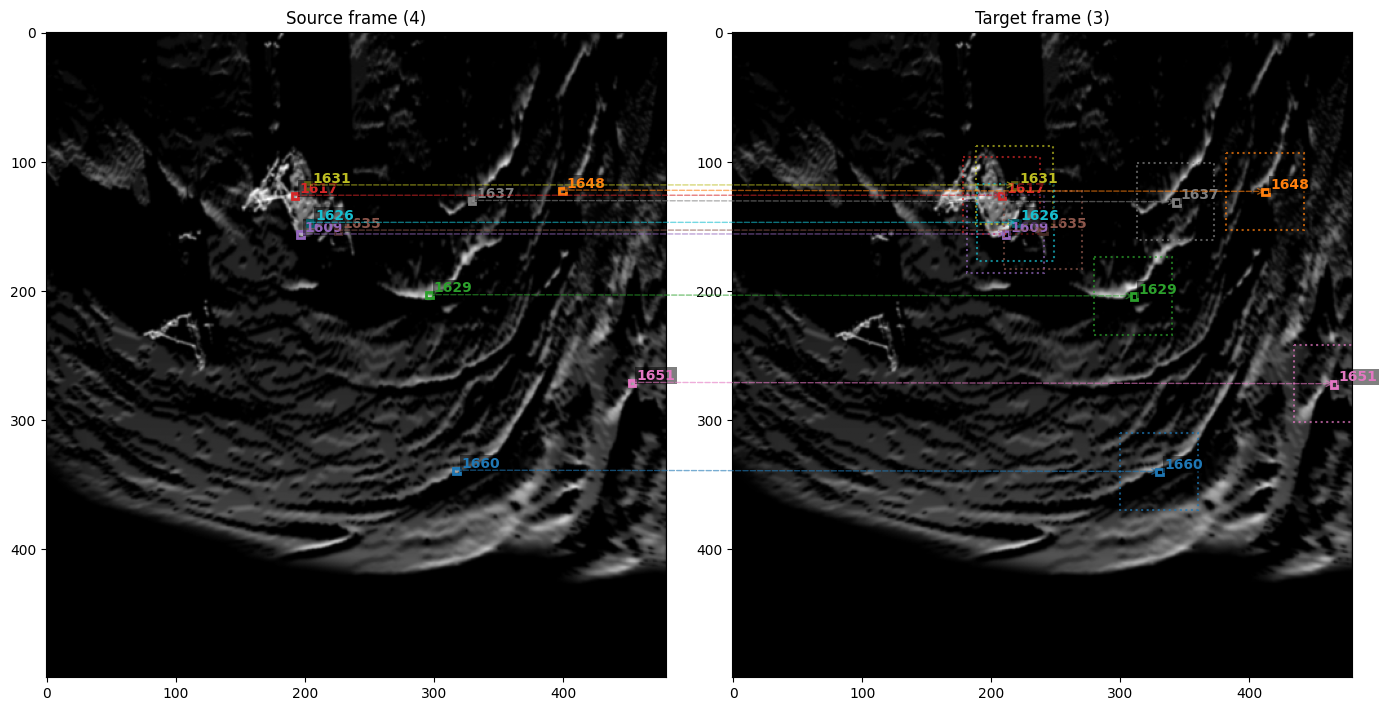

In [276]:

src_frame_np = frames[0, chosen_src, :, :].squeeze(0).detach().cpu().numpy()
tgt_frame_np = frames[0, chosen_tgt, :, :].squeeze(0).detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
ax1, ax2 = axes 

# -- read images --
ax1.imshow(src_frame_np, cmap='gray')
ax1.set_title(f"Source frame ({chosen_src})")

ax2.imshow(tgt_frame_np, cmap='gray')
ax2.set_title(f"Target frame ({chosen_tgt})")


source_coords_np = source_coords_fls.detach().cpu().numpy()
target_coords_np = target_coords_fls.detach().cpu().numpy()

search_size = (corr_neighbour + patch_size - 1) * encoder_downsize

num_patches = source_coords_np.shape[0]
colors = plt.cm.tab10(np.linspace(0, 1, num_patches))

for i in range(num_patches):
    color = colors[i]
    
    src_x = int(source_coords_np[i, 1])
    src_y = int(source_coords_np[i, 0])
    
    tgt_x = int(target_coords_np[i, 1])
    tgt_y = int(target_coords_np[i, 0])
    
    source_patch = patches.Rectangle(
        (src_x - patch_size//2, src_y - patch_size//2) * encoder_downsize, 
        patch_size, patch_size, 
        linewidth=2, edgecolor=color, facecolor='none'
    )
    ax1.add_patch(source_patch)
    
    ax1.text(src_x + patch_size//2 + 2, src_y - patch_size//2, 
             f'{edge_num[i]}', color=color, fontsize=10, fontweight='bold',
             bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

    target_patch = patches.Rectangle(
        (tgt_x - patch_size//2, tgt_y - patch_size//2) * encoder_downsize, 
        patch_size, patch_size, 
        linewidth=2, edgecolor=color, facecolor='none'
    )
    ax2.add_patch(target_patch)
    
    ax2.text(tgt_x + patch_size//2 + 2, tgt_y - patch_size//2, 
             f'{edge_num[i]}', color=color, fontsize=10, fontweight='bold',
             bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

    search_patch = patches.Rectangle(
        (tgt_x - search_size//2, tgt_y - search_size//2), 
        search_size, search_size, 
        linewidth=1.5, edgecolor=color, linestyle=':', facecolor='none', alpha=0.7
    )
    ax2.add_patch(search_patch)

    con = ConnectionPatch(
        xyA=(src_x, src_y), xyB=(tgt_x, tgt_y), 
        coordsA="data", coordsB="data",
        axesA=ax1, axesB=ax2,           
        color=color, linewidth=1, linestyle="--", alpha=0.6,
        arrowstyle="->"                
    )
    fig.add_artist(con)

plt.tight_layout()
plt.show()

In [270]:
# src_frame_np = frames[0, chosen_src, :, :].squeeze(0).detach().cpu().numpy()
# tgt_frame_np = frames[0, chosen_tgt, :, :].squeeze(0).detach().cpu().numpy()

# fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# ax1, ax2 = axes 

# # -- source frame --
# ax1.imshow(src_frame_np, cmap = 'gray')
# ax1.set_title(f"Source frame ({chosen_src})")
# # -- target frame --
# ax2.imshow(tgt_frame_np, cmap = 'gray')
# ax2.set_title(f"Target frame ({chosen_tgt})")

# # -- source patch --
# source_coords_fls = source_coords_fls.detach().cpu().numpy()
# source_coords_fls_center_x = (source_coords_fls[:, 1]).astype(np.int16)  # theta - x axis, idx 1 
# source_coords_fls_center_y = (source_coords_fls[:, 0]).astype(np.int16)  # r - y axis, idx 0 

# source_patch = patches.Rectangle(
#     (source_coords_fls_center_x - patch_size//2, source_coords_fls_center_y- patch_size//2), 
#     patch_size, patch_size, 
#     linewidth=1, edgecolor='red', facecolor='none'
# )
# ax1.add_patch(source_patch)
# ax1.text(source_coords_fls_center_x + 4*patch_size, source_coords_fls_center_y + 4*patch_size, 
#          f'Source patch\n({source_coords_fls_center_x}, {source_coords_fls_center_y})', 
#          color='red', 
#          fontsize=8, 
#          fontweight='bold',
#          ha='left') 

# # -- target patch --

# target_coords_fls_center_x = int(target_coords_fls[:, 1]) # theta - x axis, idx 1 
# target_coords_fls_center_y = int(target_coords_fls[:, 0]) # r - y axis, idx 0
# target_patch = patches.Rectangle(
#     (target_coords_fls_center_x - patch_size//2, target_coords_fls_center_y- patch_size//2), 
#     patch_size, patch_size, 
#     linewidth=1, edgecolor='red', facecolor='none'
# )
# ax2.add_patch(target_patch)
# ax2.text(target_coords_fls_center_x + 4*patch_size, target_coords_fls_center_y + 4*patch_size, 
#          f'Target patch\n({target_coords_fls_center_x}, {target_coords_fls_center_y})', 
#          color='red', 
#          fontsize=8, 
#          fontweight='bold',
#          ha='left') 



# # -- corr nieghbour patch --

# search_size = corr_neighbour + patch_size - 1

# target_coords_fls_center_x = (target_coords_fls[1]).astype(np.int16) # theta - x axis, idx 1 
# target_coords_fls_center_y = (target_coords_fls[0]).astype(np.int16)  # theta - x axis, idx 1 

# target_patch = patches.Rectangle(
#     (target_coords_fls_center_x - search_size//2, target_coords_fls_center_y- search_size//2), 
#     search_size, search_size, 
#     linewidth=1, edgecolor='lime', facecolor='none'
# )
# ax2.add_patch(target_patch)
# # ax2.text(target_coords_fls_center_x + 2*patch_size, target_coords_fls_center_y + 2*patch_size, 
# #          f'Source patch\n({target_coords_fls_center_x}, {target_coords_fls_center_y})', 
# #          color='lime', 
# #          fontsize=8, 
# #          fontweight='bold',
# #          ha='left') 

# # --- add line between patches ---
# con = ConnectionPatch(
#     xyA=(source_coords_fls_center_x, source_coords_fls_center_y), xyB=(target_coords_fls_center_x, target_coords_fls_center_y), 
#     coordsA="data", coordsB="data",
#     axesA=ax1, axesB=ax2,           
#     color="red", linewidth=0.5, linestyle="--",
#     arrowstyle="-"                
# )

# # 4. Dodajemy połączenie do całej FIGURY (nie do osi!)
# fig.add_artist(con)

In [271]:
# === Dataset statistis === 

# Calculate statistic about patches displacement on img 

batches_num = 0

r_displacement = []
theta_displacement = []

for i in range(batches_num):
    batch = next(iter(train_data_loader))
    frames, time, trajectory_gt, depth_gt = batch
        
    batch_size, frames_max = frames.shape[:2]

    init_frames = 6

    # extrinsic valibration gt -> sonar
    poses_gt = calib.pose(trajectory_gt)
    depth_gt = calib.depth(depth_gt)

    # --- Graph Init --- 

    # 1. Extraxct features (for whole series)
    # by passinf depth_gt, elevation angle is init as gt 
    coords_phi, coords_r_theta = graph.extract_features(frames, depth_gt) 

    # 3. Init edges for initial number poses
    graph.init_edges(init_frames, device)

    # 4. Calculate correlation on this initial poses
    corr, ctx, patches_idx, tgt_frames_idx, valid_mask, src_coords, tht_coords = graph.corr(poses_gt, coords_phi, coords_eps=1e-2, device=device, depth_gt = depth_gt)

    # 5. get only valid edges

    valid_mask = valid_mask.bool()

    src_frames_idx_val = patches_idx[valid_mask] // patches_per_frame
    target_frame_idx_val = tgt_frames_idx[valid_mask]
    
    source_coords_physical = src_coords[valid_mask]
    target_coords_physical = tht_coords[valid_mask]

    source_coords_fls = graph.scale_phisical2fls(source_coords_physical)
    target_coords_fls = graph.scale_phisical2fls(target_coords_physical)
    source_coords_fls = source_coords_fls.squeeze(0)
    target_coords_fls = target_coords_fls.squeeze(0)

    displacement = target_coords_fls - source_coords_fls
    r_displacement.append(displacement[:, 0])
    theta_displacement.append(displacement[:, 1])


r_displacement_tensor = torch.cat(r_displacement, dim=0)
theta_displacement_tensor = torch.cat(theta_displacement, dim=0)

# --- how many dsplacement dosent fit ro corr_nieighbour ---
threshold = corr_neighbour

total_samples = r_displacement_tensor.numel()

r_gt_11 = (r_displacement_tensor.abs() > threshold).sum().item()
theta_gt_11 = (theta_displacement_tensor.abs() > threshold).sum().item()

r_gt_11_pct = (r_gt_11 / total_samples) * 100
theta_gt_11_pct = (theta_gt_11 / total_samples) * 100

print(f"\n{'='*40}")
print(f"Displacement statistics (Threshold: {threshold}px)")
print(f"{'='*40}")

print(f"r (y axis):")
print(f"  mean: {r_displacement_tensor.abs().mean():.4f}")
print(f"  std:  {r_displacement_tensor.abs().std():.4f}")
print(f"  max:  {r_displacement_tensor.abs().max():.4f}")
print(f"  Count > {threshold}px: {r_gt_11} ({r_gt_11_pct:.2f}%)")

print(f"\ntheta (x axis):")
print(f"  mean: {theta_displacement_tensor.abs().mean():.4f}")
print(f"  std:  {theta_displacement_tensor.abs().std():.4f}")
print(f"  max:  {theta_displacement_tensor.abs().max():.4f}")
print(f"  Count > {threshold}px: {theta_gt_11} ({theta_gt_11_pct:.2f}%)")

print(f"\nTotal valid edges analyzed: {total_samples}")



# for 100 random batches:

# ========================================
# Displacement statistics (Threshold: 11px)
# ========================================
# r (y axis):
#   mean: 2.1480
#   std:  1.8410
#   max:  10.8145
#   Count > 11px: 0 (0.00%)

# theta (x axis):
#   mean: 9.0582
#   std:  12.4648
#   max:  221.6883
#   Count > 11px: 59808 (27.77%)

# Total valid edges analyzed: 215406

ValueError: torch.cat(): expected a non-empty list of Tensors



### Displacement statistics (Threshold: 11px)

r (y axis):

  mean: 2.1480

  std:  1.8410

  max:  10.8145

  Count > 11px: 0 (0.00%)


theta (x axis):

  mean: 9.0582

  std:  12.4648

  max:  221.6883

  Count > 11px: 59808 (27.77%)


Total valid edges analyzed: 215406

<!-- - prepare data  -->

<!-- ## Output test -->
